# Border-effect sanity checks: image mask vs. count-derived border

One row per sample, three columns:

1. **Image + mask/spot contours** -- the tissue image (H&E for Visium, ssDNA
   for STOmics), with the image-derived tissue mask (lime) and the
   count/grid-derived spot-occupancy footprint (pink) overlaid.
2. **Counts + border/elbow/BLADE** -- raw total counts in grid space, with
   the spot-occupancy footprint (pink), the bosperrus piecewise-linear elbow
   (blue), and the BLADE erosion-layer threshold (orange). Both are fit per
   spatially-connected component (e.g. a TMA's individual cores) and
   combined into one whole-sample raster.
3. **Image mask + outside spots** -- the image-derived mask outline, with
   every spot outside it colored by its own total count.

Thresholds come from `src/utils/border_fit.py::get_or_compute_component_fit`
(cached, shared with `ST.ipynb`).

In [1]:
import gc
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import ndimage

sys.path.insert(0, str((Path("../..") / "src" / "utils").resolve()))
import visium_hd
from border_fit import ALL_SAMPLES, FIT_PALETTE, get_grid_components, get_or_compute_component_fit, grid_border_distance

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# --- Computational parameters ---
MARGIN_FRAC = 0.05       # crop margin around qualifying spots, as a fraction of their extent
TARGET_POOL_SIZE = 800   # target long-edge resolution (px) for mask/spot pooling

In [3]:
# --- Plotting parameters ---
N_SAMPLES = len(ALL_SAMPLES)

BSPBLUE = FIT_PALETTE["Piecewise Linear Fit"]
BLADE_ORANGE = "orange"
IMAGE_MASK_COLOR = "#39FF14"   # lime
SPOT_MASK_COLOR = "#FF1493"    # deep pink

PAD = 5        # zero-pad (grid cells) so column 2's contours close at the array edge
POOL_PAD = 5   # zero-pad (pooled cells) so columns 1/3's contours close at the crop edge

## Build the figure, one row per sample

In [4]:
def process_sample_row(fig, axes_row, i):
    sample = ALL_SAMPLES["name"].iloc[i]
    loader_type = ALL_SAMPLES["loader"].iloc[i]
    h5ad_path = ALL_SAMPLES["h5ad_path"].iloc[i]
    dataset_type = ALL_SAMPLES["dataset_type"].iloc[i]
    bin_size_um = ALL_SAMPLES["bin_size_um"].iloc[i]
    print("reading", sample)

    n_counts, array_row, array_col, spatial = visium_hd.load_counts_and_coords(loader_type, h5ad_path)

    # Fit bosperrus/BLADE per spatially-connected component (e.g. a TMA's
    # cores), then combine into whole-sample arrays for a shared crop/context.
    components = get_grid_components(array_row, array_col)
    dist_to_border = np.full(len(array_row), np.nan)
    in_bsp_buffer = np.zeros(len(array_row), dtype=bool)
    component_label = np.full(len(array_row), -1)
    blade_thresh_by_component = {}
    for component_rank, member_mask, component_size in components:
        fit = get_or_compute_component_fit(sample, component_rank, component_size, h5ad_path, bin_size_um,
                                            array_row[member_mask], array_col[member_mask], n_counts[member_mask])
        dist_to_border[member_mask] = grid_border_distance(array_row[member_mask], array_col[member_mask])
        in_bsp_buffer[member_mask] = dist_to_border[member_mask] <= fit["bsp_thresh"]
        component_label[member_mask] = component_rank
        blade_thresh_by_component[component_rank] = fit["blade_thresh"]

    qual = component_label >= 0  # spots in a qualifying component; everything below is restricted to this
    qual_row, qual_col = array_row[qual], array_col[qual]

    # Orientation between grid axes and pixel axes isn't a fixed convention --
    # it varies per sample/axis, so measure it from the data.
    spatial_qual = spatial[qual].astype(np.float64)
    flip_col_axis = np.corrcoef(qual_col, spatial_qual[:, 0])[0, 1] < 0
    flip_row_axis = np.corrcoef(qual_row, spatial_qual[:, 1])[0, 1] > 0

    # --- grid-space (column 2): occupancy, bosperrus elbow, BLADE erosion-depth
    occupancy, row_off, col_off = visium_hd.rasterize_grid(qual_row, qual_col, np.ones(len(qual_row)), fill=0.0)
    occupancy_bool = occupancy > 0
    # 1px-pad before the taxicab transform so edge-touching cells read as
    # layer 1, matching peel_sweep's own binary_erosion(border_value=0).
    erosion_depth = ndimage.distance_transform_cdt(np.pad(occupancy_bool, 1, constant_values=False), metric="taxicab")[1:-1, 1:-1]
    erosion_depth_at_spot = erosion_depth[qual_row - row_off, qual_col - col_off]
    qual_component_label = component_label[qual]
    thresh_lut = np.full(max(blade_thresh_by_component, default=-1) + 1, np.inf)
    for rank, thresh in blade_thresh_by_component.items():
        thresh_lut[rank] = thresh
    in_blade_buffer_qual = erosion_depth_at_spot <= thresh_lut[qual_component_label]

    bsp_grid, _, _ = visium_hd.rasterize_grid(qual_row, qual_col, in_bsp_buffer[qual].astype(float), fill=0.0)
    blade_grid, _, _ = visium_hd.rasterize_grid(qual_row, qual_col, in_blade_buffer_qual.astype(float), fill=0.0)
    del erosion_depth, erosion_depth_at_spot, thresh_lut

    # Pad so contour() can close the boundary at the raster's own (always tight-fit) edge.
    occupancy_bool = np.pad(occupancy_bool, PAD, constant_values=False)
    bsp_grid = np.pad(bsp_grid, PAD, constant_values=0.0)
    blade_grid = np.pad(blade_grid, PAD, constant_values=0.0)
    row_off, col_off = row_off - PAD, col_off - PAD
    del occupancy

    # --- pixel-space: image mask + crop bbox (qualifying spots only)
    mask, pixel_scale = visium_hd.load_image_mask(loader_type, h5ad_path, sample)
    coords_rc = np.stack([spatial[:, 1] * pixel_scale, spatial[:, 0] * pixel_scale], axis=1)
    rounded_rc = np.clip(np.round(coords_rc).astype(int), 0, np.array(mask.shape) - 1)
    outside_mask = ~mask[rounded_rc[:, 0], rounded_rc[:, 1]] & qual
    del rounded_rc

    row_min, row_max = coords_rc[qual, 0].min(), coords_rc[qual, 0].max()
    col_min, col_max = coords_rc[qual, 1].min(), coords_rc[qual, 1].max()
    margin_row, margin_col = (row_max - row_min) * MARGIN_FRAC, (col_max - col_min) * MARGIN_FRAC
    row0, row1 = max(0, int(row_min - margin_row)), min(mask.shape[0], int(row_max + margin_row))
    col0, col1 = max(0, int(col_min - margin_col)), min(mask.shape[1], int(col_max + margin_col))

    image_crop = visium_hd.load_cropped_image(loader_type, h5ad_path, sample, row0, row1, col0, col1)
    mask_crop = mask[row0:row1, col0:col1]
    del mask

    h, w = mask_crop.shape
    factor = max(1, round(h / TARGET_POOL_SIZE))
    mask_pooled = visium_hd.block_or_pool(mask_crop, factor).astype(float)
    del mask_crop

    # Bin directly at the pooled resolution (raster-then-pool aliases into moire/crosshatch).
    h_pool, w_pool = mask_pooled.shape
    spot_hist, _, _ = np.histogram2d(
        coords_rc[qual, 0] - row0, coords_rc[qual, 1] - col0,
        bins=[h_pool, w_pool], range=[[0, h], [0, w]],
    )
    spot_pooled = ndimage.binary_closing(spot_hist > 0, structure=np.ones((3, 3))).astype(float)
    del spot_hist

    dy = h / (h_pool - 1) if h_pool > 1 else 1.0
    dx = w / (w_pool - 1) if w_pool > 1 else 1.0
    mask_pooled = np.pad(mask_pooled, POOL_PAD, constant_values=0.0)
    spot_pooled = np.pad(spot_pooled, POOL_PAD, constant_values=0.0)
    pool_y = np.linspace(-POOL_PAD * dy, h + POOL_PAD * dy, h_pool + 2 * POOL_PAD)
    pool_x = np.linspace(-POOL_PAD * dx, w + POOL_PAD * dx, w_pool + 2 * POOL_PAD)

    # === Column 1: raw image + both contours ===
    ax = axes_row[0]
    if image_crop.ndim == 2:
        ax.imshow(image_crop, cmap="gray", vmin=0, vmax=np.percentile(image_crop, 99.5))
    else:
        ax.imshow(image_crop)
    ax.contour(pool_x, pool_y, mask_pooled, levels=[0.5], colors=[IMAGE_MASK_COLOR], linewidths=1.2)
    ax.contour(pool_x, pool_y, spot_pooled, levels=[0.5], colors=[SPOT_MASK_COLOR], linewidths=1.2)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{sample} ({dataset_type}): image + mask/spot contours", fontsize=9)
    if i == 0:
        col1_handles = [
            Line2D([0], [0], color=IMAGE_MASK_COLOR, lw=1.5, label="image-derived mask"),
            Line2D([0], [0], color=SPOT_MASK_COLOR, lw=1.5, label="spot-derived footprint"),
        ]
        ax.legend(handles=col1_handles, loc="lower center", bbox_to_anchor=(0.5, 1.08),
                  ncol=2, fontsize=8, frameon=False)
    del image_crop, spot_pooled

    # === Column 2: counts + occupancy + elbow + BLADE ===
    ax = axes_row[1]
    x_coords = col_off + np.arange(occupancy_bool.shape[1])
    y_coords = row_off + np.arange(occupancy_bool.shape[0])
    ax.scatter(qual_col, qual_row, c=n_counts[qual], cmap="gray", s=1, alpha=0.5, rasterized=True)
    ax.contour(x_coords, y_coords, bsp_grid, levels=[0.5], colors=[BSPBLUE], linewidths=1.2)
    ax.contour(x_coords, y_coords, blade_grid, levels=[0.5], colors=[BLADE_ORANGE], linewidths=1.2)
    ax.contour(x_coords, y_coords, occupancy_bool.astype(float), levels=[0.5], colors=[SPOT_MASK_COLOR], linewidths=0.8)
    ax.set_aspect("equal")
    x_pad, y_pad = (x_coords[-1] - x_coords[0]) * 0.06, (y_coords[-1] - y_coords[0]) * 0.06
    if flip_col_axis:
        ax.set_xlim(x_coords[-1] + x_pad, x_coords[0] - x_pad)
    else:
        ax.set_xlim(x_coords[0] - x_pad, x_coords[-1] + x_pad)
    if flip_row_axis:
        ax.set_ylim(y_coords[-1] + y_pad, y_coords[0] - y_pad)
    else:
        ax.set_ylim(y_coords[0] - y_pad, y_coords[-1] + y_pad)
    ax.axis("off")
    ax.set_title(f"{sample}: counts + border/elbow/BLADE", fontsize=9)
    if i == 0:
        col2_handles = [
            Line2D([0], [0], color=BSPBLUE, lw=1.5, label="bosperrus elbow"),
            Line2D([0], [0], color=BLADE_ORANGE, lw=1.5, label="BLADE threshold"),
            Line2D([0], [0], color=SPOT_MASK_COLOR, lw=1.5, label="spot-derived footprint"),
        ]
        ax.legend(handles=col2_handles, loc="lower center", bbox_to_anchor=(0.5, 1.08),
                  ncol=3, fontsize=8, frameon=False)
    del occupancy_bool, bsp_grid, blade_grid

    # === Column 3: image mask + outside spots colored by counts ===
    ax = axes_row[2]
    ax.contour(pool_x, pool_y, mask_pooled, levels=[0.5], colors=["black"], linewidths=0.8)
    sca = ax.scatter(coords_rc[outside_mask, 1] - col0, coords_rc[outside_mask, 0] - row0,
                      c=n_counts[outside_mask], cmap="viridis", s=2, rasterized=True)
    fig.colorbar(sca, ax=ax, shrink=0.6, pad=0.02, label="n_counts")
    ax.set_xlim(0, w); ax.set_ylim(h, 0)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{sample}: image mask + outside spots", fontsize=9)
    del coords_rc, outside_mask, n_counts, spatial, dist_to_border, mask_pooled

    gc.collect()

reading breast_cancer
reading pancreas
reading colon_cancer_ff
reading breast_cancer_tma
reading Pat1
reading Pat2
reading Pat3
reading Pat4
reading A02991D1
reading A02994C6
reading Y01087DD
reading Y01084J8


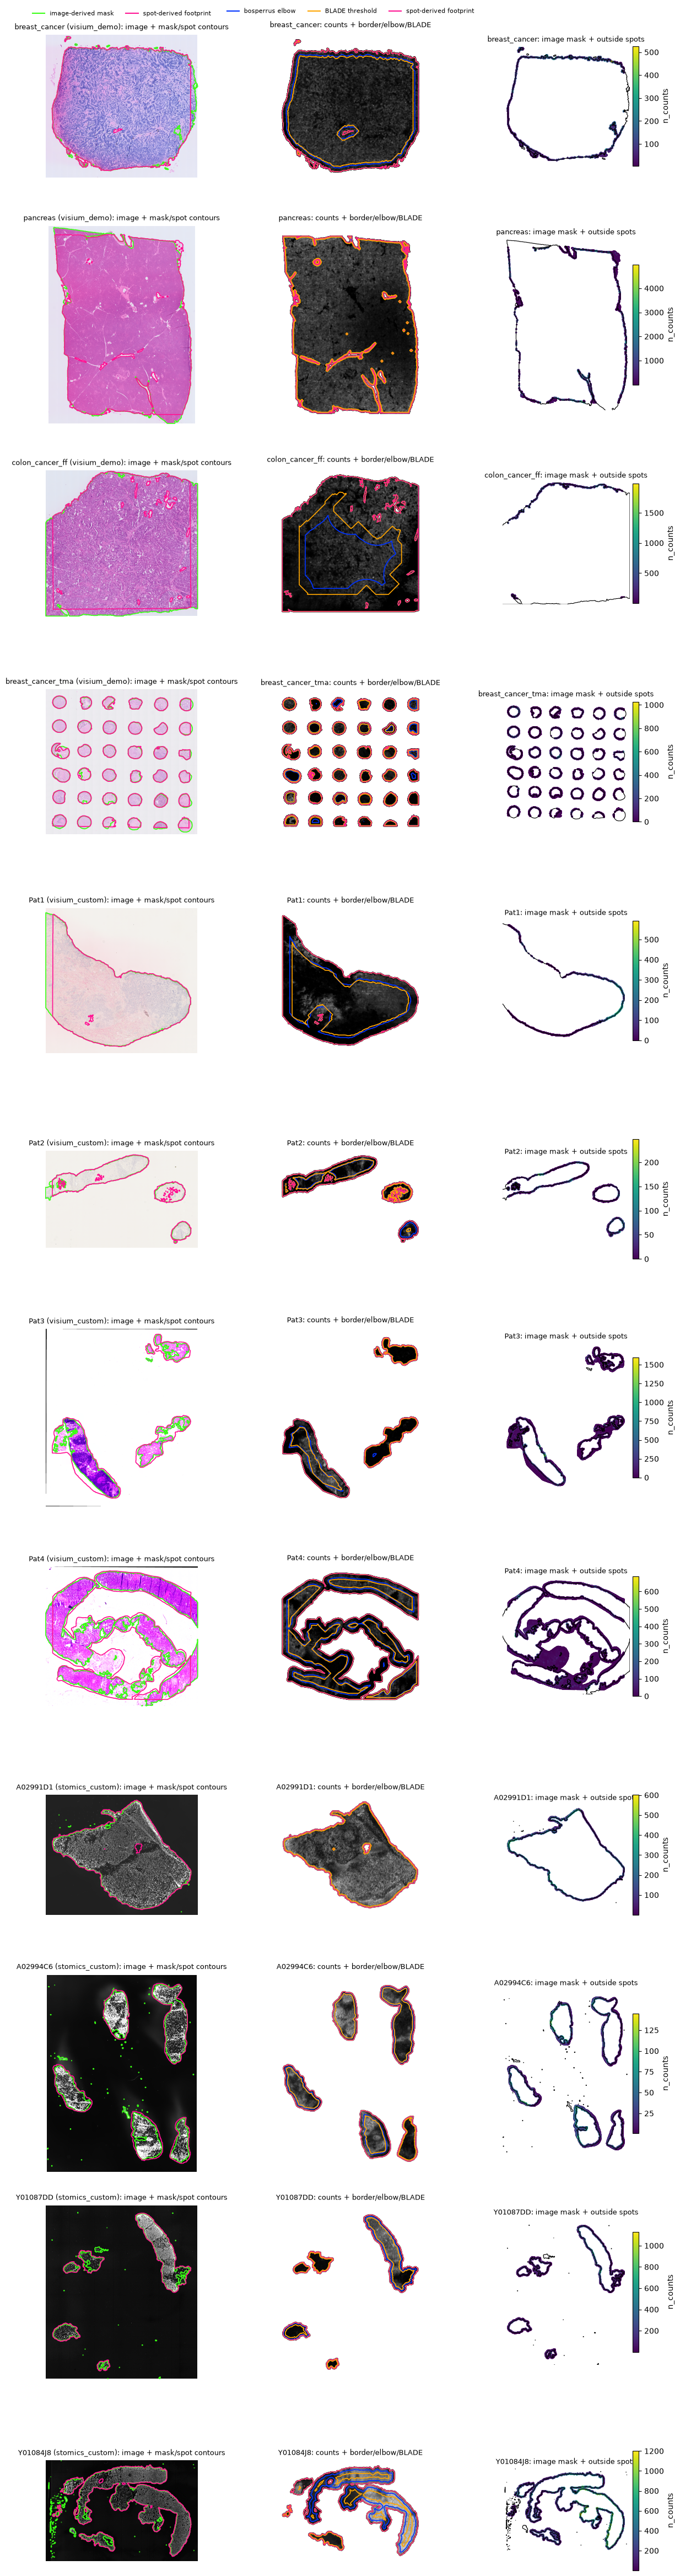

In [5]:
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
for i in range(N_SAMPLES):
    process_sample_row(fig, axes[i], i)
plt.tight_layout()
plt.show()